# This notebook shows example of plots and visualization

###                                       Supported file formats for saving the plots:
###                                                               png, pdf, svg

### plotValues(): plots values in the specific shape (from vfprogression package)
### This function plots the input VF values, sensitivity, td or pd. In addition, the functions can save the plot in the working directory as filename (e.g. 'td' in this example) with the defined format (e.g. 'png' in this example)

In [ ]:
from PyGlaucoMetrics import visualFields
print(hasattr(visualFields, '_GRID_24D2_STD'))  # must print True

True


C:\Users\mm3572\AppData\Local\anaconda3\envs\env_pyVF\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


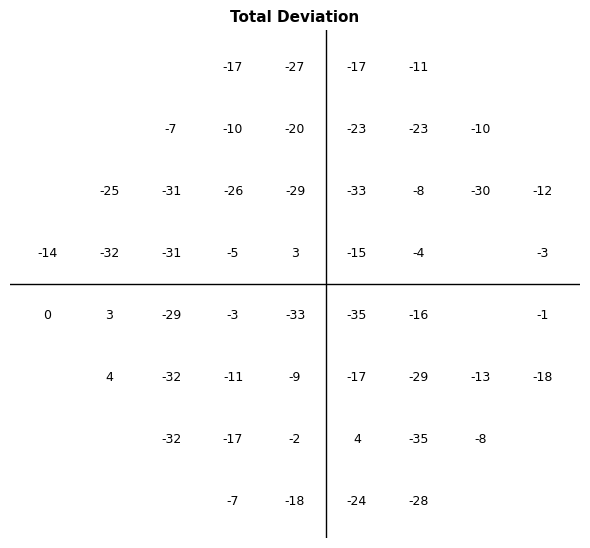

In [ ]:
from PyGlaucoMetrics import vfprogression
import numpy as np

td = np.random.randint(low=-35, high=5, size=(54,))
vfprogression.plotValues(td, title= 'Total Deviation',
                                 save=True, filename='td', fmt='png')

### plotProbabilities: plot/save probabilty e.g. tdp, pdp (from vfprogression package)

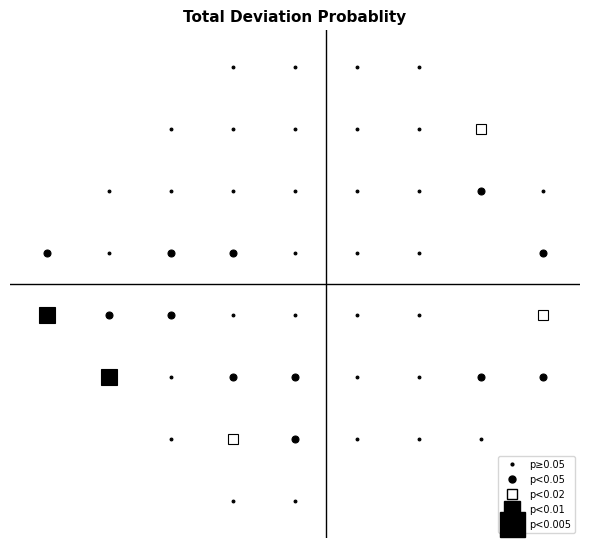

In [ ]:
from PyGlaucoMetrics import vfprogression
import numpy as np

df_VFs_py = vfprogression.data_vfseries()
vf = df_VFs_py.iloc[[5]] # get a one VF
ind_tdp_start= vf.columns.get_loc("tdp1")
ind_tdp_end= vf.columns.get_loc("tdp54") 
tdp = vf.iloc[0, ind_tdp_start:ind_tdp_end+1].to_numpy().astype(np.float16())
vfprogression.plotProbabilities(tdp, title= 'Total Deviation Probablity',
                                 save=True, filename='tdp', fmt='png')  

### Another example:
#### In this example, we derive the data of vfpwgRetest24d2() function (from visualFields package) and make it compatible with vfprogression packag to make the plot.

#### Description: Once vfpwgRetest24d2() is used, we can use getallvalues() function to compute probability values. 
#### plotProbabilities (from vfprogression package) plots the total deviation probability map and also saves it in the working directoty with 'png' format. 

Shape of Total Deviation: (54,)


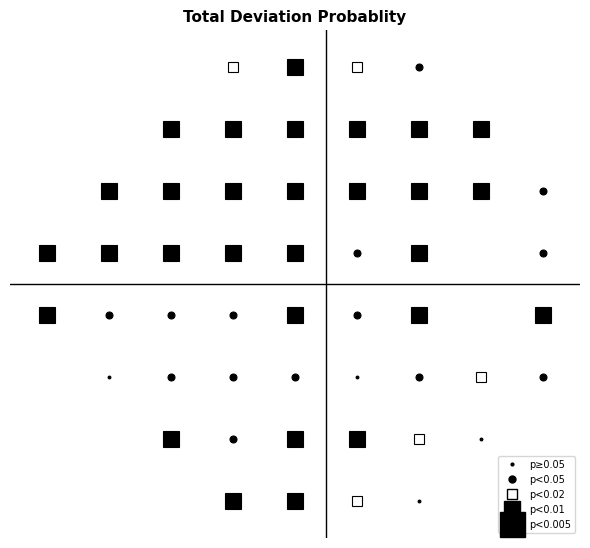

In [ ]:
from PyGlaucoMetrics import visualFields
from PyGlaucoMetrics import vfprogression
import numpy as np

df_VFs_py = visualFields.data_vfpwgRetest24d2()
df_td, df_tdp, df_gi, df_gip, df_pd, df_pdp, gh = visualFields.getallvalues(df_VFs_py)

# TD columns are now named td1..td54
ind_td_start = df_td.columns.get_loc("td1")
ind_td_end   = df_td.columns.get_loc("td54")

df_td  = df_td.fillna(0)
df_tdp = df_tdp.fillna(0)

td  = df_td.iloc[0, ind_td_start:ind_td_end+1].to_numpy().astype(np.int8)
print('Shape of Total Deviation:', td.shape)

# TDP columns are named tdp1..tdp54
ind_tdp_start = df_tdp.columns.get_loc("tdp1")
ind_tdp_end   = df_tdp.columns.get_loc("tdp54")
tdp = df_tdp.iloc[0, ind_tdp_start:ind_tdp_end+1].to_numpy().astype(np.float16)

vfprogression.plotProbabilities(tdp, title='Total Deviation Probablity',
                                save=True, filename='tdp', fmt='png')

### vfplot: plots a single visual field test (from visualFields package)
#### based on the input type, it can plot sensitivity(s), td, pd, tds (td & s), pds (pd & s) 
#### deviations maps are colorful and the colormap can be accessed by plotProbColormap
#### Description: vfplot function also saves the photo with filename (e.g. 'file' in this example) with the format (e.g. 'png' in this example.). 

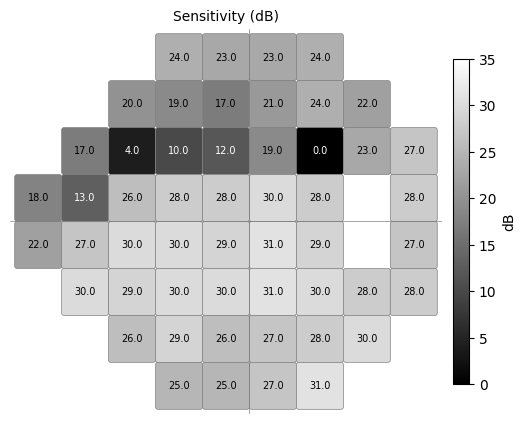

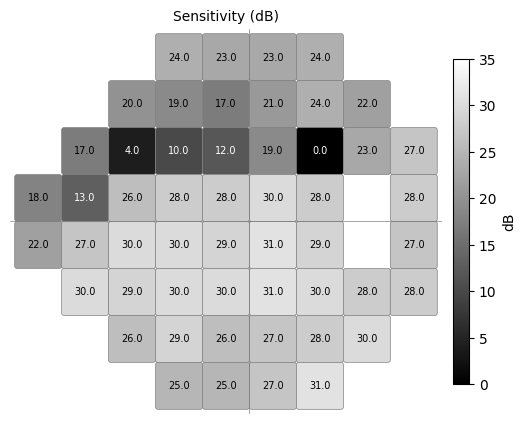

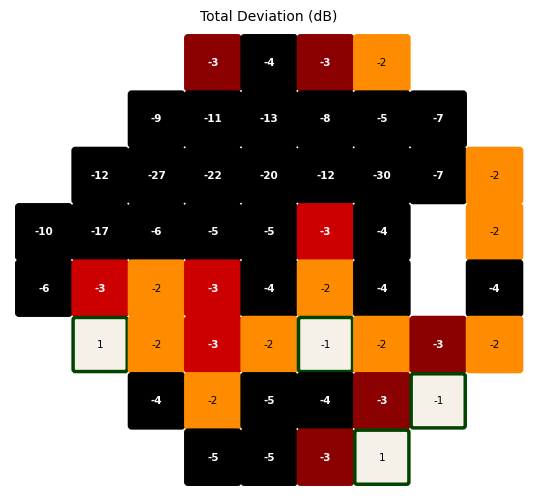

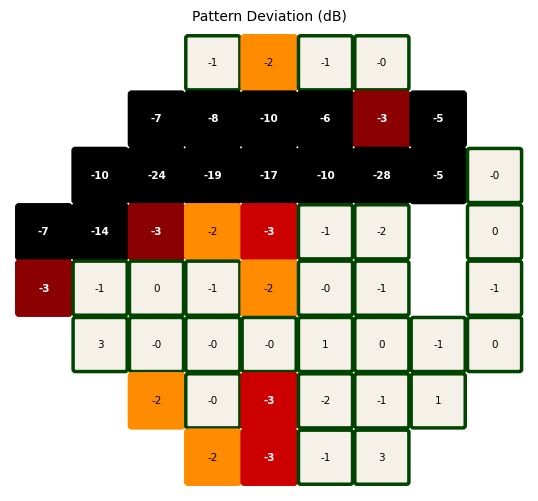

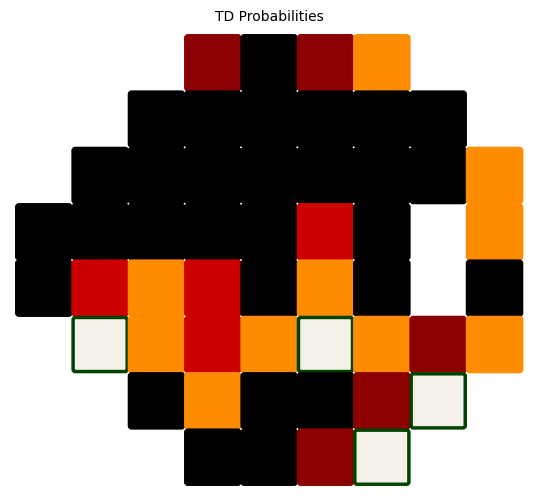

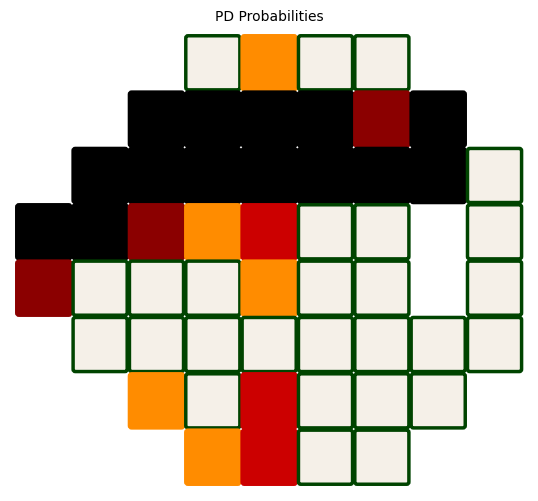

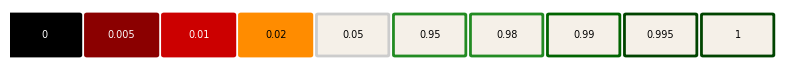

In [ ]:
from PyGlaucoMetrics import visualFields

df_VFs_py = visualFields.data_vfpwgRetest24d2() #df_VFs_py is acquired using vfpwgRetest24d2() function. 
vf = df_VFs_py.iloc[[0]] #lets pick the first VF of df_VFs_py as example

visualFields.vfplot(vf, type='s', save=True, filename='file', fmt='png') # types: s, td,pd, tds, pds
visualFields.vfplot_s(vf, save=False, filename='s', fmt='png') # alias for vfplot(type='s')
visualFields.vfplot_td(vf, save=True, filename='td', fmt='png') # alias for vfplot(type='td')
visualFields.vfplot_pd(vf, save=True, filename='pd', fmt='pdf') # alias for vfplot(type='pd')
visualFields.vfplot_tds(vf, save=True, filename='tds', fmt='png') # alias for vfplot(type='tds')
visualFields.vfplot_pds(vf, save=True, filename='pds', fmt='png') # alias for vfplot(type='pds')
visualFields.plotProbColormap(save=True, filename='cmap', fmt='png') # show colormap of probablies (from visualFields package)

### vfplotsparklines: plot sparklines (from visualFields package)

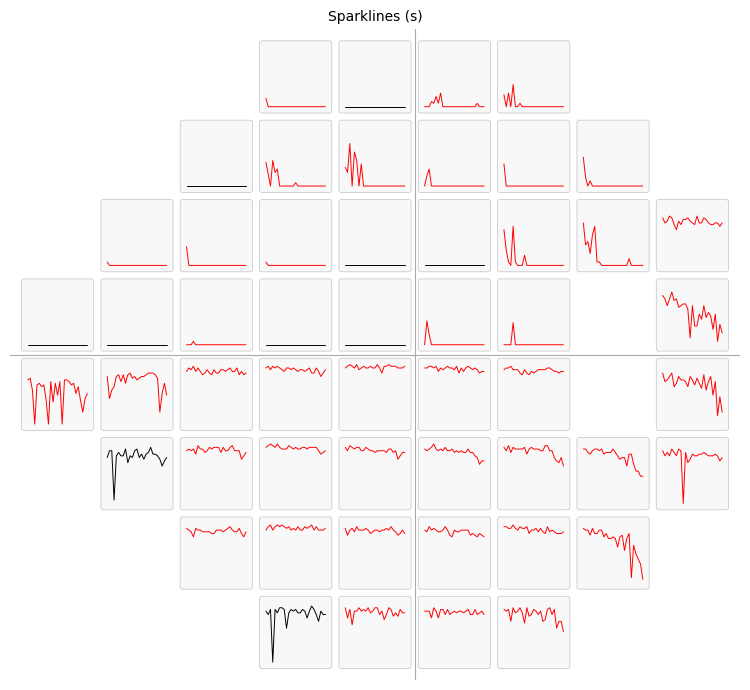

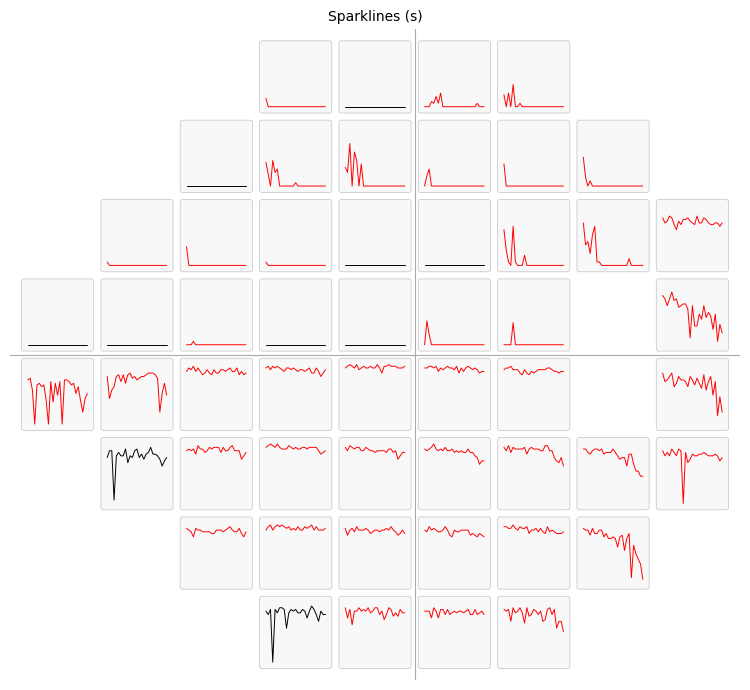

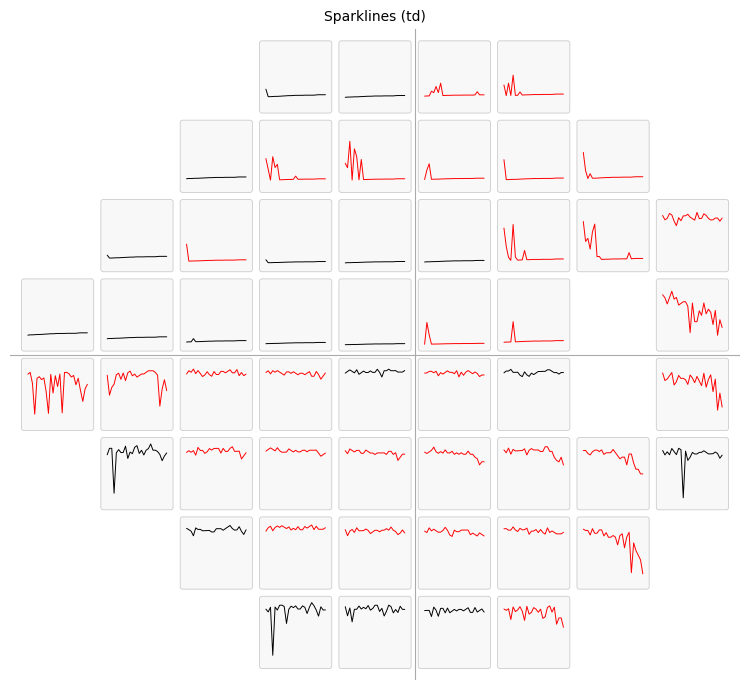

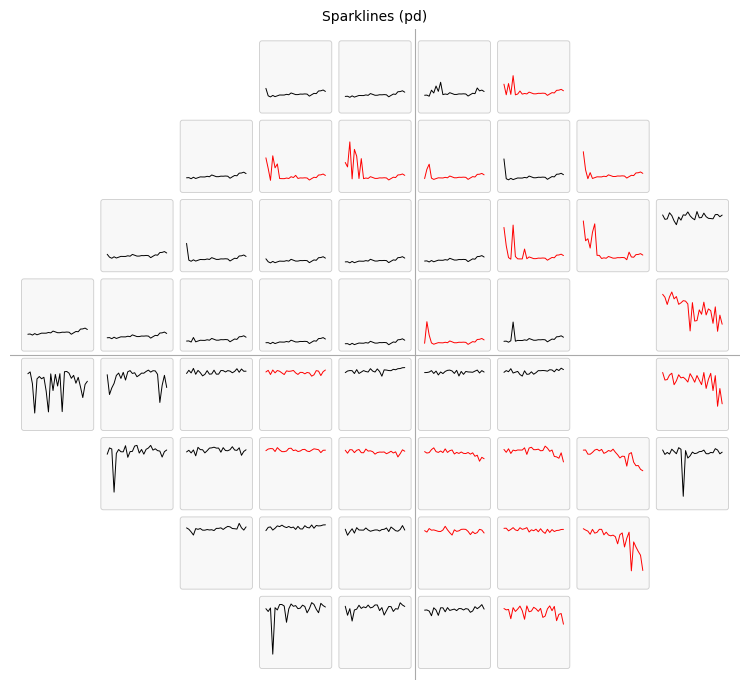

In [ ]:
from PyGlaucoMetrics import visualFields

df_VFs_py = visualFields.data_vfpwgSunyiu24d2()#df_VFs_py is acquired using vfpwgRetest24d2() function.
filter1 = df_VFs_py.id=='sample1'
filter2 = df_VFs_py.eye=='OD'
df_vf_1 = df_VFs_py.loc[ filter1 & filter2]

visualFields.vfplotsparklines(df_vf_1, type='s', save=True, filename='file', fmt='png') # types: s, td, pd 
visualFields.vfplotsparklines_s(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotsparklines(type='s')
visualFields.vfplotsparklines_td(df_vf_1, save=True, filename='file', fmt='png')# alias for vfplotsparklines(type='td')
visualFields.vfplotsparklines_pd(df_vf_1, save=True, filename='file', fmt='png')# alias for vfplotsparklines(type='pd')

### vfplotplr plots the results of pointwise linear regression for a series of visual fields for an eye from a subject. (from visualFields package).

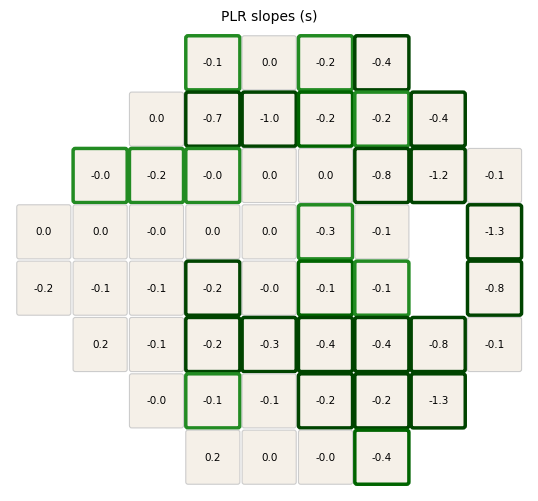

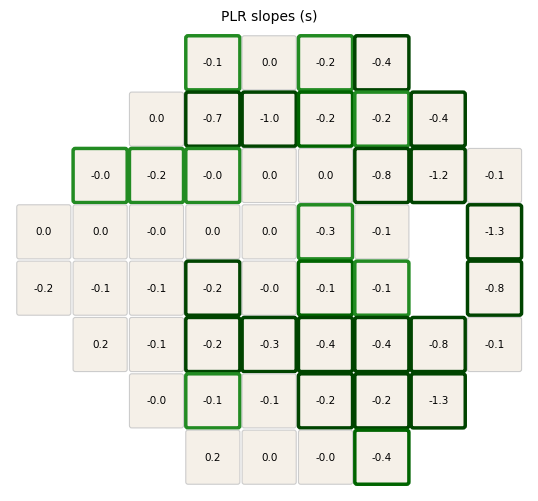

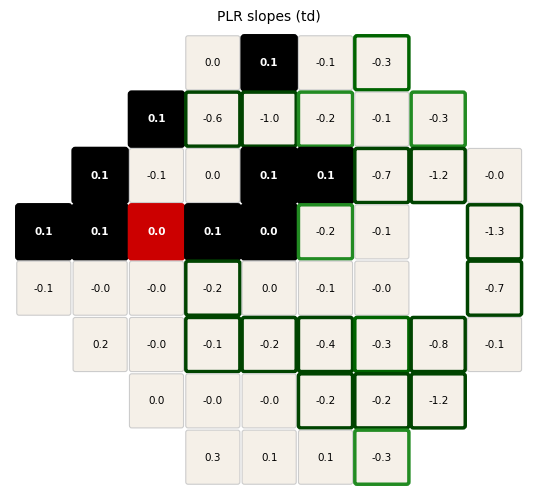

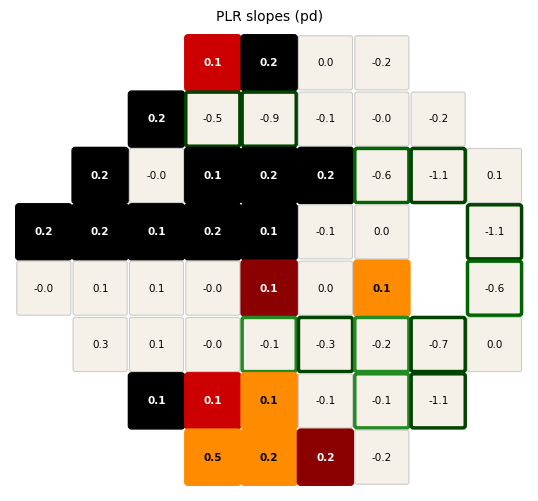

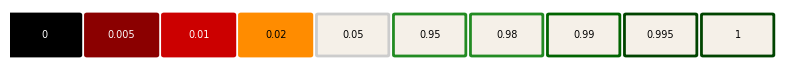

In [ ]:
from PyGlaucoMetrics import visualFields

df_VFs_py = visualFields.data_vfpwgSunyiu24d2()#df_VFs_py data is acquired using vfpwgRetest24d2() function.
filter1 = df_VFs_py.id=='sample1'
filter2 = df_VFs_py.eye=='OD'
df_vf_1 = df_VFs_py.loc[ filter1 & filter2]

visualFields.vfplotplr(df_vf_1, type='s', save=True, filename='file', fmt='png') # types: s, td, pd
visualFields.vfplotplr_s(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotplr(type='s')
visualFields.vfplotplr_td(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotplr(type='td')
visualFields.vfplotplr_pd(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotplr(type='pd')
visualFields.plotProbColormap(save=True, filename='file', fmt='png') # This function generates color scale.

In [ ]:
import pandas as pd, numpy as np
from scipy.stats import linregress

df = pd.read_csv(r"C:\Users\mm3572\PyVisualField\src\PyGlaucoMetrics\data\vfctrSunyiu24d2.csv")
scols = sorted([c for c in df.columns if c.startswith('l') and c[1:].isdigit()],
               key=lambda x: int(x[1:]))
ages = df['age'].values.astype(float)

intercepts, slopes = [], []
for col in scols:
    y = df[col].values.astype(float)
    mask = ~np.isnan(y)
    if mask.sum() >= 3:
        sl, ic, *_ = linregress(ages[mask], y[mask])
    else:
        sl, ic = -0.08, 30.0
    intercepts.append(ic); slopes.append(sl)

out = r"C:\Users\mm3572\PyVisualField\src\PyGlaucoMetrics\data\normvals_sunyiu24d2.csv"
pd.DataFrame({'intercept': intercepts, 'slope': slopes}).to_csv(out, index=False)
print(f"Saved {len(intercepts)} normative points")

Saved 54 normative points


### vflegoplot:  the legoplot shows the differences between the average values of visual field tests taken as baseline and those at the end of follow up (from visualFields package). 

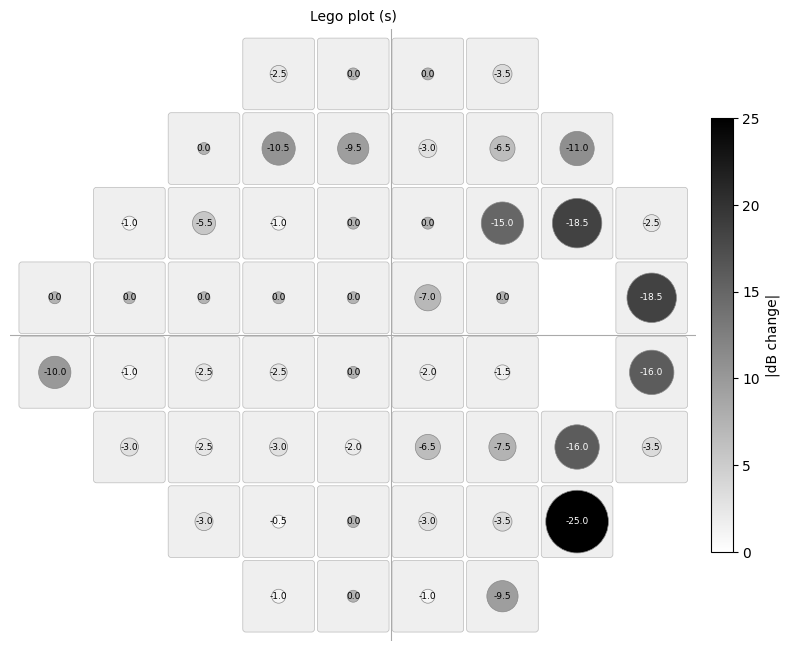

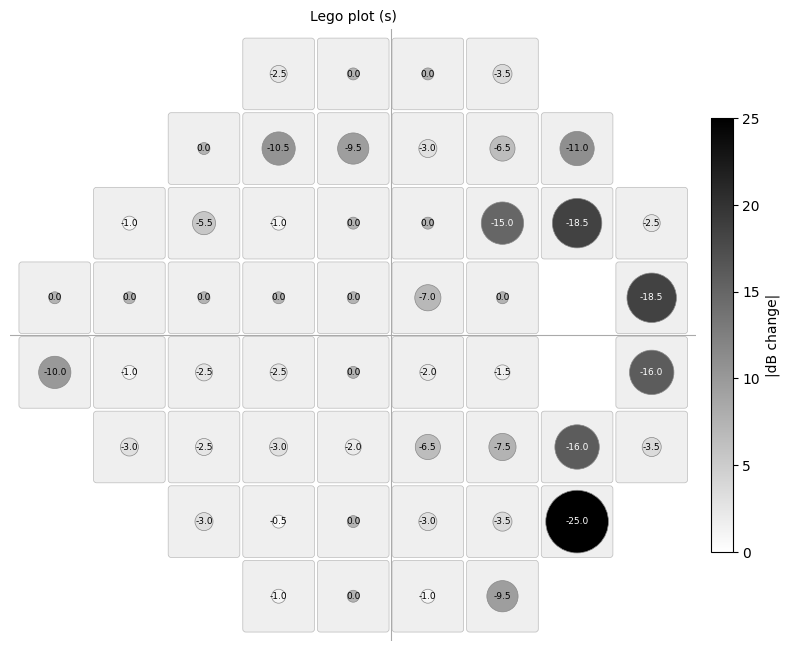

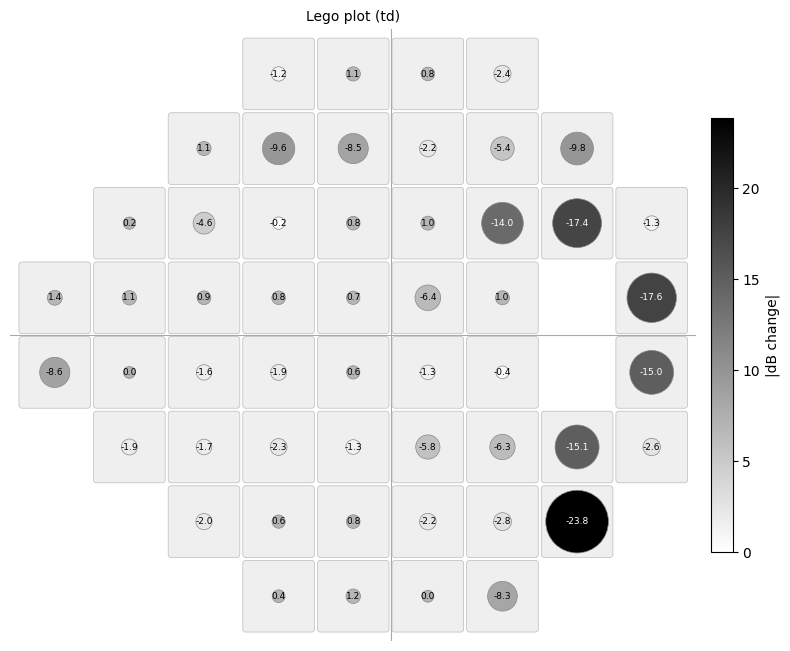

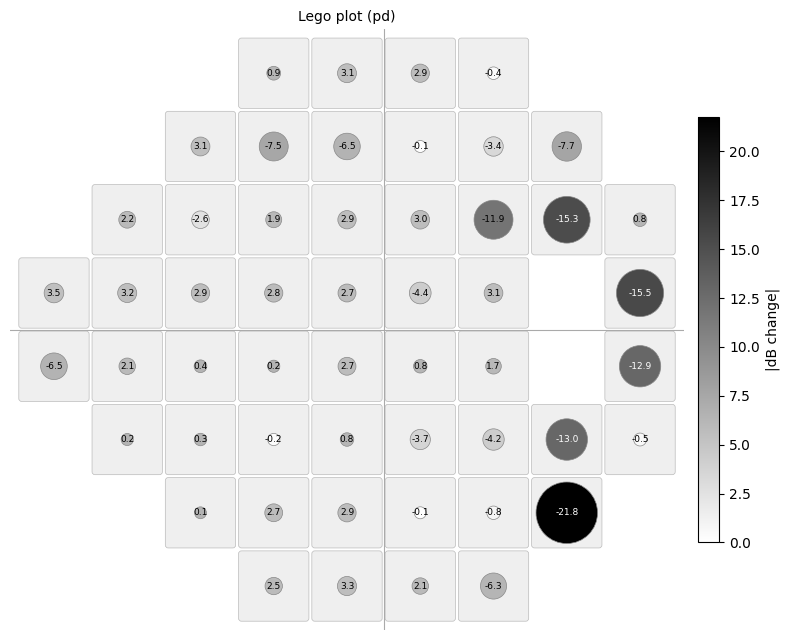

In [ ]:
from PyGlaucoMetrics import visualFields

df_VFs_py = visualFields.data_vfpwgSunyiu24d2()#df_VFs_py data is acquired using vfpwgRetest24d2() function.
filter1 = df_VFs_py.id=='sample1'
filter2 = df_VFs_py.eye=='OD'
df_vf_1 = df_VFs_py.loc[ filter1 & filter2]

visualFields.vflegoplot(df_vf_1, type='s', save=True, filename='file', fmt='png') # types: s, td, pd
visualFields.vflegoplot_s(df_vf_1, save=True, filename='file', fmt='png') # alias for vflegoplot(type='s')
visualFields.vflegoplot_td(df_vf_1, save=True, filename='file', fmt='png') # alias for vflegoplot(type='td')
visualFields.vflegoplot_pd(df_vf_1, save=True, filename='file', fmt='png') # alias for vflegoplot(type='pd')

### vfsfa: Single Field Reporting (from visualFields package)

#### Description: Generates a one-page report of single field analyses.

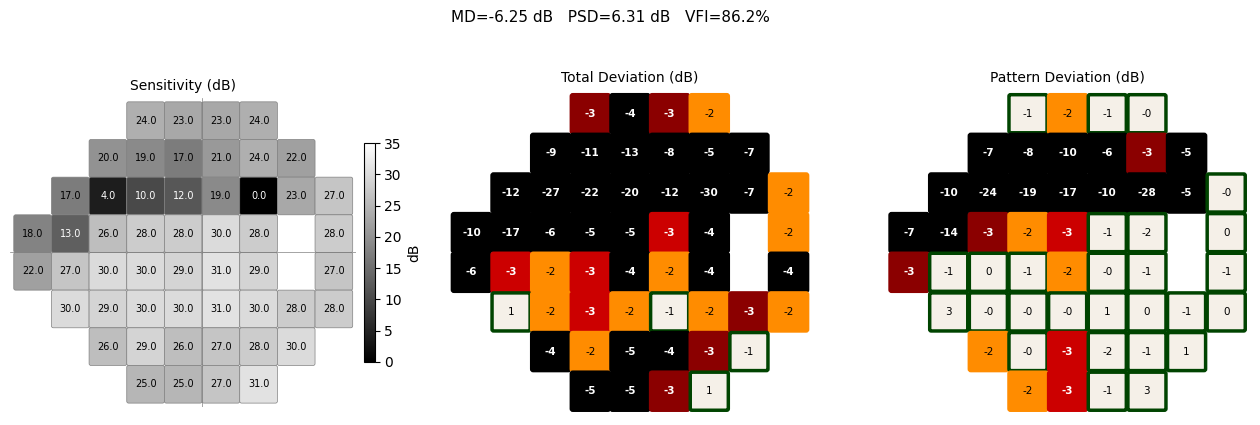

Saved: report.pdf


In [ ]:
from PyGlaucoMetrics import visualFields

df_VFs_py = visualFields.data_vfpwgRetest24d2()#df_VFs_py is acquired using vfpwgRetest24d2() function. 
vf = df_VFs_py.iloc[[0]]#vf is the first row of df_VFs_py 

visualFields.vfsfa(vf, 'report.pdf')